# QuFoods Exploration — Data Profiling, Quality Issues, and Imputation Validation

Owner: Siyan (Adetu Siyanbola) — Exploration workstream, Implementation Plan tasks #8–22.

This notebook builds directly on `qufoods_starter_notebook.ipynb` — same `list_recent_keys` / `load_batches` ingestion approach, same `clean_order_items` typo-fix mechanics — but moves the reusable logic into the `exploration` package (`src/exploration/`) so it can be imported by Emmanuel's Lambda, tested with `pytest`, and run unattended. This notebook is the **narrative layer** on top of that package: it calls the package functions and explains *why* each decision was made, which is what actually needs to go in the data quality log and the team deck.

**Run modes:** by default this runs against the bundled sample batch in `data/sample_batches/` (zero AWS dependency — works the moment you clone the repo). Flip `USE_S3 = True` below once IAM access to `qufoods-raw` is confirmed, and every cell below runs unchanged against the live feed.

## Setup

In [1]:
import sys
sys.path.insert(0, '../src')  # exploration package lives in exploration/src/exploration

import pandas as pd
import matplotlib.pyplot as plt

from exploration.pipeline import run, split_record_types
from exploration.ingest import pull_batches
from exploration.reference import load_branches, load_menu_items, FLAGGED_BRANCHES
from exploration.profiling import field_profile, branch_quality_profile, compare_flagged_vs_other, duplicate_summary
from exploration.cleaning import clean_order_items, TYPO_MATCH_CUTOFF
from exploration.imputation import validate_formula, formula_total

%matplotlib inline
pd.set_option('display.max_columns', None)

In [2]:
# Flip to True once IAM access (s3:ListBucket + s3:GetObject on qufoods-raw) is confirmed.
# Every cell below is unchanged either way -- this is the only switch.
USE_S3 = False

AWS_PROFILE = 'qufoods'   # set to None to use your default AWS credential chain
LOOKBACK_MINUTES = 1440   # wide window for exploration; production Lambda uses 5
SAMPLE_DIR = '../data/sample_batches'

## Part 1 — Pull raw batches

Same approach as the starter notebook's `list_recent_keys` + `load_batches`, wrapped behind `pull_batches()` so the local/live switch is one argument instead of two different code paths to maintain. The bundled sample batch (`BATCH-96bd24c2...`) is the exact one pulled from the public URL given in the lab brief.

In [3]:
ingest_result = pull_batches(use_s3=USE_S3, minutes=LOOKBACK_MINUTES, profile=AWS_PROFILE, sample_dir=SAMPLE_DIR)
raw_df = ingest_result.raw_df

print(f"{len(ingest_result.source_keys)} batch file(s) loaded")
print(f"{len(raw_df)} total records")
raw_df.sample(1).to_dict(orient='records')[0]

1 batch file(s) loaded
26 total records


{'record_id': 'e6ca8e1d-265c-4839-bb7f-1188b21ca0da',
 'record_type': 'EXPENSE',
 'batch_id': 'BATCH-96bd24c2-7124-4fb5-93e8-f016bd600d67',
 'branch_id': 'BR-02',
 'branch_name': 'QuFoods Lekki',
 'branch_manager': nan,
 'transaction_id': nan,
 'membership_id': nan,
 'order_channel': nan,
 'order_items': nan,
 'order_subtotal': nan,
 'discount_applied': nan,
 'total_amount': nan,
 'payment_method': nan,
 'transaction_status': nan,
 'order_source': nan,
 'customer_arrival_time': nan,
 'customer_departure_time': nan,
 'ingested_at': '2026-06-17T15:45:38Z',
 'expense_category': 'STAFF_WELFARE',
 'amount': 11184.57,
 'currency': 'NGN',
 'raised_by': 'Blessing Olawale',
 'approved_by': 'Chinwe Danjuma',
 'paid_by': 'Yusuf Okonkwo',
 'approval_status': 'APPROVED',
 'expense_date': '2026-05-30'}

## Part 2 — Split sales vs. expenses

~95% sales, ~5% expense per the brief — worth confirming that holds, since a wildly different split on a real pull would be a signal something upstream changed.

In [4]:
sales_df, expense_df = split_record_types(raw_df)

print('sales:  ', sales_df.shape, f"({len(sales_df)/len(raw_df):.0%} of batch)")
print('expense:', expense_df.shape, f"({len(expense_df)/len(raw_df):.0%} of batch)")

sales:   (22, 19) (85% of batch)
expense: (4, 14) (15% of batch)


## Part 3 — Field profiling (Task #10)

Null rate, dtype, distinct count, and (for numerics) min/max per column. Run separately on sales and expense since they're different schemas after the split.

In [5]:
sales_profile = field_profile(sales_df)
sales_profile

,column,dtype,null_count,null_rate,n_distinct,min,max
0,membership_id,str,17,0.7727,5,NaN,NaN
1,total_amount,float64,3,0.1364,19,492.38,12172.71
2,branch_name,str,1,0.0455,12,NaN,NaN
3,batch_id,str,0,0.0000,1,NaN,NaN
4,record_type,str,0,0.0000,1,NaN,NaN
5,record_id,str,0,0.0000,22,NaN,NaN
6,branch_manager,str,0,0.0000,12,NaN,NaN
7,transaction_id,str,0,0.0000,22,NaN,NaN
8,order_channel,str,0,0.0000,3,NaN,NaN
9,order_items,str,0,0.0000,22,NaN,NaN


In [6]:
expense_profile = field_profile(expense_df)
expense_profile

,column,dtype,null_count,null_rate,n_distinct,min,max
0,branch_name,str,1,0.25,2,NaN,NaN
1,record_id,str,0,0.00,4,NaN,NaN
2,record_type,str,0,0.00,1,NaN,NaN
3,batch_id,str,0,0.00,1,NaN,NaN
4,branch_id,str,0,0.00,3,NaN,NaN
5,ingested_at,str,0,0.00,1,NaN,NaN
6,expense_category,str,0,0.00,3,NaN,NaN
7,amount,float64,0,0.00,4,2193.03,40602.35
8,currency,str,0,0.00,1,NaN,NaN
9,raised_by,str,0,0.00,4,NaN,NaN


**Reading the null rates:** not every null is a data quality problem. `membership_id` being null most of the time is a *real value* — most customers are walk-ins, not members. `approved_by` being null on expenses means the expense hasn't been approved yet — also real. The nulls that actually matter are `total_amount` (the brief's named issue) and `branch_name`/`branch_manager` (a digitisation artifact, fixed in Part 5).

## Part 4 — Branch-level quality deep dive (Task #11)

The brief specifically calls out **BR-06, BR-07** (Ogun State) and **BR-15, BR-16, BR-17** (south-east) as having known data discipline issues. Confirming this with evidence rather than taking it on faith — and checking whether any *other* branch is quietly just as bad, since the brief explicitly says these aren't the only ones.

In [7]:
branch_quality = branch_quality_profile(sales_df, expense_df)
branch_quality.sort_values('total_amount_null_rate', ascending=False)

,branch_id,n_sales_records,total_amount_null_rate,branch_name_null_rate,membership_null_rate,is_flagged_branch,n_expense_records
7,BR-12,1,1.0000,0.0000,0.0000,False,0
4,BR-07,2,0.5000,0.0000,1.0000,True,0
1,BR-02,3,0.3333,0.0000,0.6667,False,2
0,BR-01,3,0.0000,0.0000,0.6667,False,1
3,BR-06,2,0.0000,0.0000,0.5000,True,0
2,BR-03,2,0.0000,0.0000,1.0000,False,0
5,BR-08,1,0.0000,0.0000,0.0000,False,0
6,BR-10,1,0.0000,0.0000,1.0000,False,0
8,BR-13,3,0.0000,0.3333,1.0000,False,0
9,BR-16,1,0.0000,0.0000,1.0000,True,0


In [8]:
compare_flagged_vs_other(branch_quality)

,total_amount_null_rate,branch_name_null_rate,membership_null_rate
is_flagged_branch,,,
other_branches,0.1481,0.037,0.7037
flagged_branches,0.1667,0.000,0.8333


**Note on sample size:** the bundled sample batch is a single ~26-record file — too small for this flagged-vs-other comparison to be statistically meaningful on its own. Once pulling across multiple dates from the live bucket (`USE_S3 = True`, wider `LOOKBACK_MINUTES`), re-run this cell and look for the gap between flagged and non-flagged branches to widen. If it doesn't, that's itself a finding worth documenting — it would mean the brief's branch-specific framing doesn't fully hold and the real quality issues are more evenly distributed than described.

## Part 5 — Repair branch fields from the reference registry

`branch_name` / `branch_manager` nulls are a digitisation artifact, not a real gap — `branch_id` is never null and the registry is always internally consistent. Recovered via lookup, not dropped. (`exploration.branch_repair.repair_branch_fields` — same logic as the starter notebook's Part 5, factored into the package.)

In [9]:
from exploration.branch_repair import repair_branch_fields

before = sales_df['branch_name'].isna().mean()
sales_df = repair_branch_fields(sales_df)
after = sales_df['branch_name'].isna().mean()
print(f"branch_name null rate: {before:.1%} -> {after:.1%}")

branch_name null rate: 4.5% -> 0.0%


## Part 6 — Lock the region mapping (Task #12) and confirm the menu list (Task #13)

Region mapping is a business decision (which states count as "West" vs "Other"), locked once in `exploration.reference.STATE_TO_REGION` so Bukolami's schema and Daniel's regional reports use the same definition. The 13-item menu list comes straight from `reference_menu_items.csv`.

In [10]:
branches = load_branches()
branches[['branch_id', 'branch_name', 'state', 'region']]

,branch_id,branch_name,state,region
0,BR-01,QuFoods Ikeja,Lagos,Lagos
1,BR-02,QuFoods Lekki,Lagos,Lagos
2,BR-03,QuFoods Victoria Island,Lagos,Lagos
3,BR-04,QuFoods Ibadan Central,Oyo,West
4,BR-05,QuFoods Bodija,Oyo,West
5,BR-06,QuFoods Abeokuta,Ogun,West
6,BR-07,QuFoods Sagamu,Ogun,West
7,BR-08,QuFoods Akure,Ondo,West
8,BR-09,QuFoods Osogbo,Osun,West
9,BR-10,QuFoods Abuja Wuse,FCT,Other


In [11]:
branches['region'].value_counts()

region
Other    11
West      6
Lagos     3
Name: count, dtype: int64

In [12]:
menu_items = load_menu_items()
print(f"{len(menu_items)} canonical menu items:")
menu_items

13 canonical menu items:


['jollof rice',
 'fried rice',
 'ofada rice',
 'burger',
 'chicken wings',
 'grilled fish',
 'plantain',
 'coleslaw',
 'puff puff',
 'coke',
 'zobo',
 'water',
 'chapman']

## Part 7 — Misspelling correction (Tasks #14–15)

`exploration.cleaning.clean_order_items` mirrors the starter notebook's mechanics but swaps `difflib` for `rapidfuzz` and changes the cutoff from the implementation plan's suggested 85% down to **75%** — backed by evidence, not a guess. See the module docstring in `src/exploration/cleaning.py` for the full reasoning; short summary below.

In [13]:
from exploration.cleaning import score_candidates, correct_item_name

# The real typos found in this sample batch:
real_typos = ['ocke', 'ckoe', 'chickne wings', 'ofada irce', 'chicekn wings']
for typo in real_typos:
    scores = score_candidates(typo, menu_items)
    print(f"{typo!r:20s} -> best match {scores[0]}")

'ocke'               -> best match ('coke', 75.0)
'ckoe'               -> best match ('coke', 75.0)
'chickne wings'      -> best match ('chicken wings', 92.3)
'ofada irce'         -> best match ('ofada rice', 90.0)
'chicekn wings'      -> best match ('chicken wings', 92.3)


**Why 75 and not the plan's suggested 85:** at 85, `"ocke"` and `"ckoe"` — both real typos of `"coke"` — score only 75, so they'd silently fail to get corrected. Short item names lose more similarity percentage per swapped letter than long ones (a 4-letter swap on `coke` costs far more than a 1-letter swap on `chicken wings`). Checking the other direction — genuinely off-menu Nigerian dishes (`suya`, `amala`, `moi moi`, `akara`, `beans`) — the highest any of them scores against this menu is 50. That leaves a wide, evidence-backed gap between 50 and 75 with nothing observed in between, so 75 is the cutoff actually used in `TYPO_MATCH_CUTOFF`.

In [14]:
off_menu_dishes = ['spaghetti carbonara', 'pizza', 'suya', 'amala', 'moi moi', 'akara', 'beans']
for dish in off_menu_dishes:
    scores = score_candidates(dish, menu_items)
    print(f"{dish!r:20s} -> best match {scores[0]}")

'spaghetti carbonara' -> best match ('plantain', 37.0)
'pizza'              -> best match ('chapman', 33.3)
'suya'               -> best match ('coleslaw', 33.3)
'amala'              -> best match ('chapman', 50.0)
'moi moi'            -> best match ('zobo', 36.4)
'akara'              -> best match ('ofada rice', 40.0)
'beans'              -> best match ('burger', 36.4)


In [15]:
cleaned = sales_df['order_items'].apply(lambda v: clean_order_items(v, menu_items, TYPO_MATCH_CUTOFF))
sales_df['order_items_clean'] = cleaned.apply(lambda t: t[0])
sales_df['order_items_typo_fixed'] = cleaned.apply(lambda t: t[1])

n_fixed = sales_df['order_items_typo_fixed'].sum()
print(f"typo-fixed {n_fixed} of {len(sales_df)} orders")
sales_df.loc[sales_df['order_items_typo_fixed'], ['order_items', 'order_items_clean']]

typo-fixed 5 of 22 orders


,order_items,order_items_clean
10,ocke,coke
12,"burger, ofada rice(x2), ckoe","burger, ofada rice(x2), coke"
17,chickne wings,chicken wings
19,"ofada irce, zobo(x2), coke(x2), grilled fish","ofada rice, zobo(x2), coke(x2), grilled fish"
20,"burger, chicekn wings","burger, chicken wings"


## Part 8 — Validate the imputation formula (Task #16)

**This is the single most important finding in the whole exploration phase.** The brief and the architecture diagram describe the relationship as `order_subtotal - discount_applied = total_amount` (flat subtraction). Testing that against real records with all three fields present shows it's wrong — `discount_applied` is a **fraction (0–1)**, a discount *rate*, not a currency amount. The correct relationship is **multiplicative**: `total_amount = order_subtotal * (1 - discount_applied)`.

In [16]:
# Negative control -- proves the brief's literal wording is wrong
sample_check = sales_df.dropna(subset=['order_subtotal', 'discount_applied', 'total_amount'])
sample_check = sample_check[sample_check['discount_applied'] > 0].head(5)

sample_check['naive_subtraction'] = sample_check['order_subtotal'] - sample_check['discount_applied']
sample_check['correct_multiplicative'] = formula_total(sample_check['order_subtotal'], sample_check['discount_applied'])

sample_check[['transaction_id', 'order_subtotal', 'discount_applied', 'total_amount', 'naive_subtraction', 'correct_multiplicative']]

,transaction_id,order_subtotal,discount_applied,total_amount,naive_subtraction,correct_multiplicative
1,TXN-34756404,7366.85,0.12,6482.83,7366.73,6482.8280
3,TXN-89285617,3484.39,0.18,2857.20,3484.21,2857.1998
4,TXN-99073169,3006.26,0.14,2585.38,3006.12,2585.3836
8,TXN-15589199,4059.53,0.08,3734.77,4059.45,3734.7676
14,TXN-18740961,11439.04,0.12,10066.36,11438.92,10066.3552


In [17]:
result = validate_formula(sales_df)
print(result)
print(f"match rate: {result.match_rate:.1%} on {result.n_checked} complete rows")
result.example_mismatches

FormulaValidationResult(n_checked=19, n_match=19, match_rate=100.00%)
match rate: 100.0% on 19 complete rows


,transaction_id,order_subtotal,discount_applied,total_amount,predicted_total


## Part 9 — Decide the imputation method (Task #17) and apply it (Tasks #18–19)

Given the formula validates near-100% on complete rows, the strategy is:

1. **Algebraic solve first** — whenever exactly one of `{order_subtotal, discount_applied, total_amount}` is missing, solve for it directly from the other two. No model needed, no training data needed, and it's *exact*, not an estimate.
2. **Regression fallback** — only for the rarer case where 2+ fields are missing at once and the algebraic solve has nothing to work with. Trained on features that don't depend on the missing fields themselves (`branch_id`, `order_channel`, `payment_method`, item count) so it stays usable on exactly the rows that need it.

In [18]:
from exploration.imputation import apply_algebraic_imputation, build_regression_fallback, apply_regression_fallback, sanity_check_imputed

n_missing_before = sales_df['total_amount'].isna().sum()
sales_df = apply_algebraic_imputation(sales_df)
n_algebraic = (sales_df['imputation_method'] == 'algebraic').sum()
print(f"missing total_amount before: {n_missing_before}")
print(f"resolved algebraically: {n_algebraic}")

missing total_amount before: 3
resolved algebraically: 3


In [19]:
model = build_regression_fallback(sales_df)
sales_df = apply_regression_fallback(sales_df, model)

n_still_missing = sales_df['total_amount'].isna().sum()
print(f"still missing after algebraic pass: {n_still_missing}")
print(f"regression model trained: {model is not None}")

still missing after algebraic pass: 0
regression model trained: False


**Note:** the bundled sample batch is too small to have any rows with 2+ missing fields at once, and too small (well under the 30-row `MIN_TRAINING_ROWS` threshold) to train a real regression model — so `model` will be `None` here, and the fallback path falls back further to a branch-level median. This is exactly the kind of thing that needs re-validating once pulling a real multi-day sample from the live bucket.

## Part 10 — Sanity check imputed values (Task #20)

**Note on a bug found during review:** the original version of this check compared `total_amount` against `order_subtotal` to catch implausible imputed values — but on rows where `order_subtotal` is *also* missing (the regression-fallback case), that comparison silently evaluates to `NaN`, which pandas treats as falsy. The check was passing every regression-fallback row by accident, regardless of how implausible the predicted value was. Fixed by branching explicitly: use the subtotal comparison when a subtotal exists, fall back to a branch-median-based heuristic (flag anything >3x or <1/3 of the branch's typical total) when it doesn't.

In [20]:
sales_df = sanity_check_imputed(sales_df)
n_implausible = sales_df['imputation_flagged_implausible'].sum()
print(f"imputed rows flagged as implausible: {n_implausible}")
sales_df[sales_df['imputation_flagged_implausible']]

imputed rows flagged as implausible: 0


,record_id,record_type,batch_id,branch_id,branch_name,branch_manager,transaction_id,membership_id,order_channel,order_items,order_subtotal,discount_applied,total_amount,payment_method,transaction_status,order_source,customer_arrival_time,customer_departure_time,ingested_at,order_items_clean,order_items_typo_fixed,total_amount_imputed,imputation_method,imputation_flagged_implausible


## Part 11 — Other data quality issues found (Task #21)

Beyond the two issues the brief names explicitly, here's what else turned up. Full detail and resolution reasoning lives in `DATA_QUALITY_LOG.md` at the repo root — this is the short version inline.

### order_subtotal range sanity

`order_subtotal` is the one money field the brief describes as "always present" and never imputed — so if it's ever negative, zero, or implausibly large, that's an upstream data problem, not something to impute around. Flagging anything non-positive outright, and anything above an IQR-based outlier fence (adapts to real branch spend patterns rather than a hardcoded NGN figure tuned to this one sample batch).

In [21]:
from exploration.profiling import plausibility_checks

plausibility = plausibility_checks(sales_df)
print(f"subtotal anomalies: {plausibility['n_subtotal_anomalies']} (upper fence: NGN {plausibility['subtotal_upper_fence_used']:,.2f})")
plausibility['subtotal_anomalies']

subtotal anomalies: 0 (upper fence: NGN 24,354.66)


,transaction_id,branch_id,order_subtotal,reason


### Empty order_items on a COMPLETED sale

A completed transaction with a populated `total_amount` but no items listed implies money changed hands for nothing — a real anomaly, not just "zero items sold." Checked separately from FAILED transactions, where an empty `order_items` is plausible (the order may have failed before items were attached).

In [22]:
print(f"empty order_items on COMPLETED sales: {plausibility['n_empty_items_on_completed_sales']}")
plausibility['empty_items_on_completed_sales']

empty order_items on COMPLETED sales: 0


,transaction_id,branch_id,total_amount,transaction_status


### Duplicate ID check

In [23]:
dup_sales = duplicate_summary(sales_df, 'transaction_id')
dup_expense = duplicate_summary(expense_df, 'record_id')
print('sales duplicates:  ', dup_sales)
print('expense duplicates:', dup_expense)

sales duplicates:   {'id_column': 'transaction_id', 'present': True, 'total_rows': 22, 'distinct_ids': 22, 'duplicate_id_count': 0, 'duplicate_row_count': 0, 'example_duplicate_ids': []}
expense duplicates: {'id_column': 'record_id', 'present': True, 'total_rows': 4, 'distinct_ids': 4, 'duplicate_id_count': 0, 'duplicate_row_count': 0, 'example_duplicate_ids': []}


In [24]:
# transaction_status includes FAILED -- these still have a populated total_amount,
# meaning 'revenue by branch' naively summed would overstate real revenue unless filtered.
sales_df['transaction_status'].value_counts()

transaction_status
COMPLETED    19
FAILED        3
Name: count, dtype: int64

In [25]:
# order_source vs order_channel sometimes disagree (e.g. order_channel=IN_STORE but
# order_source=ONLINE) -- worth flagging to Bukolami as a schema question: which field
# is authoritative for channel-based reporting?
pd.crosstab(sales_df['order_channel'], sales_df['order_source'])

order_source,ONLINE,PHYSICAL
order_channel,,
IN_STORE,2,9
ONLINE,8,1
PHONE,1,1


In [26]:
# customer_departure_time before customer_arrival_time on at least one record
# (timestamp data entry issue, not a calculation bug) -- check for it explicitly:
ts = sales_df[['transaction_id', 'customer_arrival_time', 'customer_departure_time']].copy()
ts['arrival'] = pd.to_datetime(ts['customer_arrival_time'])
ts['departure'] = pd.to_datetime(ts['customer_departure_time'])
ts['negative_dwell'] = ts['departure'] < ts['arrival']
ts[ts['negative_dwell']]

,transaction_id,customer_arrival_time,customer_departure_time,arrival,departure,negative_dwell
9,TXN-23712831,2026-06-17T17:43:21Z,2026-06-17T17:14:21Z,2026-06-17 17:43:21+00:00,2026-06-17 17:14:21+00:00,True
17,TXN-48475184,2026-06-17T20:19:08Z,2026-06-17T20:14:08Z,2026-06-17 20:19:08+00:00,2026-06-17 20:14:08+00:00,True


## Part 12 — Quick analytics pass (sanity check, not the final report)

Same charts as the starter notebook's Part 8, run on the cleaned + imputed frame instead of the naive one — just to eyeball that nothing looks structurally broken before handing off.

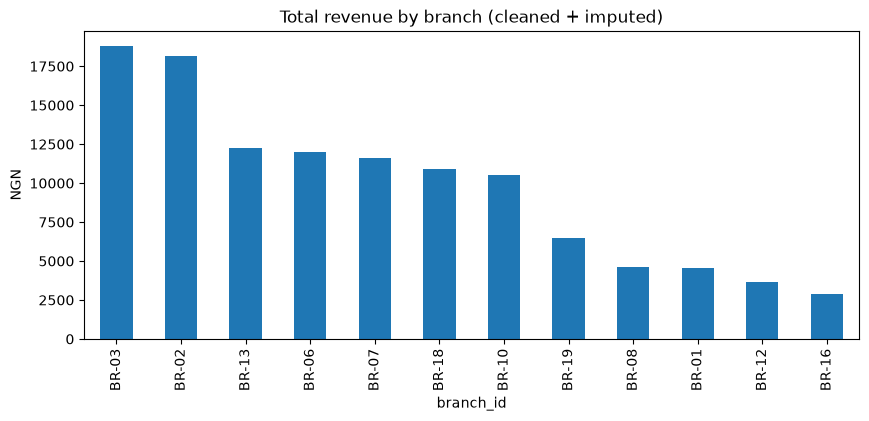

In [27]:
revenue_by_branch = sales_df.groupby('branch_id')['total_amount'].sum().sort_values(ascending=False)
revenue_by_branch.plot(kind='bar', figsize=(10, 4), title='Total revenue by branch (cleaned + imputed)')
plt.ylabel('NGN')
plt.show()

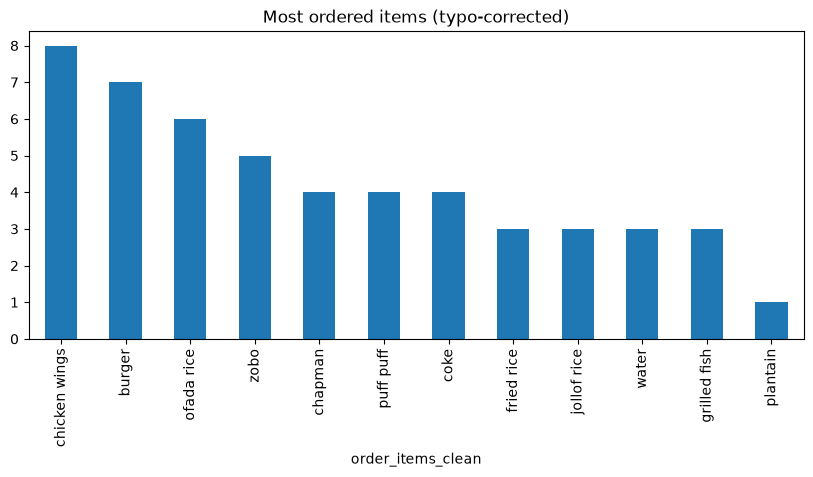

In [28]:
item_counts = (
    sales_df['order_items_clean']
    .str.split(', ')
    .explode()
    .str.replace(r'\(x\d+\)$', '', regex=True)
    .value_counts()
)
item_counts.plot(kind='bar', figsize=(10, 4), title='Most ordered items (typo-corrected)')
plt.show()

## Part 13 — Package for handoff to Emmanuel (Task #22)

Everything above is also available as a single function call — `exploration.pipeline.run()` — so Emmanuel's Lambda cleaning module doesn't need to re-derive any of this logic; it imports from this package directly. See `HANDOFF.md` at the repo root for the full contract (function signatures, what each one expects/returns, and exactly which constants are safe to import rather than copy).

In [29]:
from exploration.pipeline import run

result = run(use_s3=USE_S3, minutes=LOOKBACK_MINUTES, profile=AWS_PROFILE, sample_dir=SAMPLE_DIR)

print(f"raw records:              {result.raw_record_count}")
print(f"sales / expense:          {len(result.sales_df)} / {len(result.expense_df)}")
print(f"typo corrections:         {result.n_typo_corrections}")
print(f"algebraic imputations:    {result.n_algebraic_imputations}")
print(f"regression imputations:   {result.n_regression_imputations}")
print(f"flagged as implausible:   {result.n_implausible_imputations}")
print(f"formula match rate:       {result.formula_validation.match_rate:.1%}")

raw records:              26
sales / expense:          22 / 4
typo corrections:         5
algebraic imputations:    3
regression imputations:   0
flagged as implausible:   0
formula match rate:       100.0%


### Next steps for this section

1. Re-run this whole notebook with `USE_S3 = True` the moment IAM access to `qufoods-raw` is confirmed — pull several days' worth of files, not just the one sample batch, and re-check every conclusion above (especially the flagged-vs-other branch comparison and the regression fallback, both of which need more data than one batch provides to mean anything).
2. Update `DATA_QUALITY_LOG.md` with anything new that turns up on the larger pull.
3. Hand off `src/exploration/` to Emmanuel as-is — it's already an importable package (`pip install -e .`), so his Lambda cleaning module can `from exploration.cleaning import clean_order_items` and `from exploration.imputation import apply_algebraic_imputation` directly instead of re-implementing.

In [ ]:
sales_df.head(20)


,record_id,record_type,batch_id,branch_id,branch_name,branch_manager,transaction_id,membership_id,order_channel,order_items,order_subtotal,discount_applied,total_amount,payment_method,transaction_status,order_source,customer_arrival_time,customer_departure_time,ingested_at,order_items_clean,order_items_typo_fixed,total_amount_imputed,imputation_method,imputation_flagged_implausible
0,2c179892-181d-45a2-b594-48a55a445819,SALE,BATCH-96bd24c2-7124-4fb5-93e8-f016bd600d67,BR-01,QuFoods Ikeja,Chukwuemeka Obi,TXN-08141880,MBR-761782,IN_STORE,zobo(x3),1457.55,0.00,1457.5500,TRANSFER,COMPLETED,PHYSICAL,2026-06-17T12:11:44Z,2026-06-17T12:35:44Z,2026-06-17T15:45:38Z,zobo(x3),False,False,None,False
1,06b167d7-9c74-4954-afd1-0f48e69943e7,SALE,BATCH-96bd24c2-7124-4fb5-93e8-f016bd600d67,BR-19,QuFoods Kano,Musa Abdullahi,TXN-34756404,NaN,ONLINE,"fried rice, jollof rice, chapman(x2)",7366.85,0.12,6482.8300,TRANSFER,FAILED,ONLINE,2026-06-17T20:20:11Z,2026-06-17T20:31:11Z,2026-06-17T15:45:38Z,"fried rice, jollof rice, chapman(x2)",False,False,None,False
2,423e9cf7-72f6-46be-8a71-859ef99931cd,SALE,BATCH-96bd24c2-7124-4fb5-93e8-f016bd600d67,BR-10,QuFoods Abuja Wuse,Kelechi Nnamdi,TXN-88200897,NaN,IN_STORE,"plantain, burger(x2), chicken wings",10494.33,0.00,10494.3300,CASH,COMPLETED,ONLINE,2026-06-17T12:52:01Z,2026-06-17T13:07:01Z,2026-06-17T15:45:38Z,"plantain, burger(x2), chicken wings",False,False,None,False
3,b1d3ea1b-5def-431e-b5f7-1434abf7f478,SALE,BATCH-96bd24c2-7124-4fb5-93e8-f016bd600d67,BR-16,QuFoods Onitsha,Obinna Eze,TXN-89285617,NaN,ONLINE,burger,3484.39,0.18,2857.2000,TRANSFER,COMPLETED,ONLINE,2026-06-17T19:38:03Z,2026-06-17T20:15:03Z,2026-06-17T15:45:38Z,burger,False,False,None,False
4,82bbe75d-7b80-4da4-9944-056c45c9a243,SALE,BATCH-96bd24c2-7124-4fb5-93e8-f016bd600d67,BR-01,QuFoods Ikeja,Chukwuemeka Obi,TXN-99073169,NaN,IN_STORE,"chicken wings, water",3006.26,0.14,2585.3800,CASH,COMPLETED,PHYSICAL,2026-06-17T19:36:25Z,2026-06-17T20:16:25Z,2026-06-17T15:45:38Z,"chicken wings, water",False,False,None,False
5,28c60bf3-e706-4d15-afe5-1aefcd83f17a,SALE,BATCH-96bd24c2-7124-4fb5-93e8-f016bd600d67,BR-13,QuFoods Warri,Blessing Ovwigho,TXN-71927582,NaN,IN_STORE,"chicken wings, burger",6039.33,0.00,6039.3300,CASH,COMPLETED,PHYSICAL,2026-06-17T18:20:51Z,2026-06-17T18:51:51Z,2026-06-17T15:45:38Z,"chicken wings, burger",False,False,None,False
6,874621e8-59f4-4a8c-90a9-8100455178e1,SALE,BATCH-96bd24c2-7124-4fb5-93e8-f016bd600d67,BR-02,QuFoods Lekki,Adaeze Nwosu,TXN-02932889,NaN,ONLINE,puff puff,665.05,0.00,665.0500,POS,COMPLETED,ONLINE,2026-06-17T18:16:14Z,2026-06-17T18:47:14Z,2026-06-17T15:45:38Z,puff puff,False,True,algebraic,False
7,da08ff68-4903-4d9b-932b-ffbfa3128bff,SALE,BATCH-96bd24c2-7124-4fb5-93e8-f016bd600d67,BR-07,QuFoods Sagamu,Oluwaseun Fasanya,TXN-03933799,NaN,IN_STORE,"jollof rice, ofada rice",6308.03,0.00,6308.0300,CASH,COMPLETED,PHYSICAL,2026-06-17T19:52:24Z,2026-06-17T20:15:24Z,2026-06-17T15:45:38Z,"jollof rice, ofada rice",False,False,None,False
8,5746d1bf-8b08-4b05-8114-4904e93c7346,SALE,BATCH-96bd24c2-7124-4fb5-93e8-f016bd600d67,BR-13,QuFoods Warri,Blessing Ovwigho,TXN-15589199,NaN,ONLINE,"coke, burger",4059.53,0.08,3734.7700,POS,COMPLETED,ONLINE,2026-06-17T11:51:44Z,2026-06-17T12:32:44Z,2026-06-17T15:45:38Z,"coke, burger",False,False,None,False
9,c98df619-a9ca-4800-9a8f-04123aa8ba69,SALE,BATCH-96bd24c2-7124-4fb5-93e8-f016bd600d67,BR-12,QuFoods Port Harcourt,Ifeanyi Okonkwo,TXN-23712831,MBR-065721,IN_STORE,"grilled fish, water",4400.12,0.17,3652.0996,POS,COMPLETED,PHYSICAL,2026-06-17T17:43:21Z,2026-06-17T17:14:21Z,2026-06-17T15:45:38Z,"grilled fish, water",False,True,algebraic,False


: 